<a href="https://colab.research.google.com/github/hernandez-figueroa/Metodos-Numericos-2/blob/main/Tarea1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regla compuesta de Simpson
#Tarea 1:
**Nombre:** [Hernandez Figueroa Cristofer Alexander]

**El objetivo es:** Programar la regla compuesta de Simpson y probarla con el ejercio de la tarea 1:

$$\int_0^2 e^{2x}\sin(3x)\,dx \quad \text{con error} < 10^{-4}$$


In [3]:
import numpy as np
def f(x):
  return np.exp (2*x)*np.sin(3*x)
def simpson_compuesta(f, a, b, n):
    if n % 2 != 0:  # n debe ser par
        raise ValueError("n debe de ser par")
    h= (b-a)/ n
    XI0= f(a) + f(b)  #extremos
    XI1= 0.0          #suma de nodos impares
    XI2= 0.0          #suma de nodos pares
    for i in range(1,n):
      X=a+i*h
      if i % 2 == 0:
        XI2 += f(X)
      else:
          XI1 += f(X)
    return h*(XI0 + 2*XI2 + 4*XI1) /3
a, b, n= 0, 2, 64
I= simpson_compuesta(f, a, b, n)


# valor exacto, para comprobar
exacta= (np.exp(2*b)*(2*np.sin(3*b) - 3*np.cos(3*b))+3)/13
print("h=",(b-a)/n)
print("Simpson=", I)
print("Exacta=", exacta)
print("Error=", abs(I- exacta))


h= 0.03125
Simpson= -14.21397093969567
Exacta= -14.21397712986252
Error= 6.190166850217338e-06


## Solución del ejercicio 1

Derivadas de $f(x)=e^{2x}\sin(3x)$:

$$f''(x)=e^{2x}(12\cos 3x-5\sin 3x) \;\Rightarrow\; |f''(x)|\le 13e^{4}=M_2\approx 709.78$$

$$f^{(4)}(x)=-e^{2x}(119\sin 3x+120\cos 3x) \;\Rightarrow\; |f^{(4)}(x)|\le 169e^{4}=M_4\approx 9227.09$$

**a) Trapezoidal:** $\dfrac{(b-a)h^2}{12}M_2<10^{-4} \Rightarrow n\ge 2175.28$

$$n=2176,\quad h=\frac{2}{2176}\approx 0.000919$$

**b) Simpson:** $\dfrac{(b-a)h^4}{180}M_4<10^{-4} \Rightarrow n\ge 63.64$

$$n=64,\quad h=0.03125$$

**c) Punto medio:** $\dfrac{(b-a)h^2}{24}M_2<10^{-4} \Rightarrow n\ge 1538.15$

$$n=1539,\quad h=\frac{2}{1539}\approx 0.001299$$

# **Resultado final (Simpson, n = 64):** $I \approx -14.213971$\

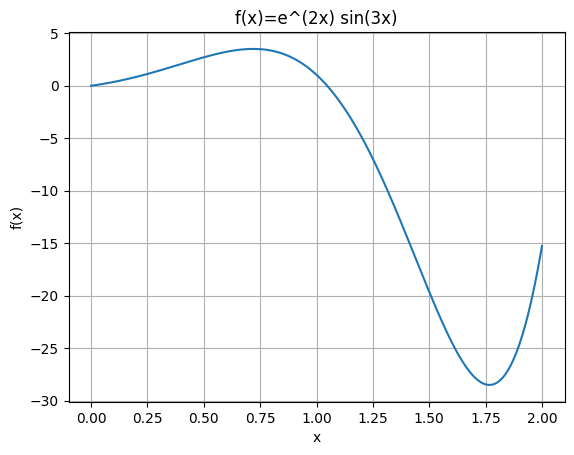

In [4]:
import matplotlib.pyplot as plt
x= np.linspace(0, 2, 300)
plt.plot(x, f(x))
plt.title("f(x)=e^(2x) sin(3x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()